# Práctica Integradora - Implementación de un Data Warehouse en BigQuery

**Integrantes:** 

- Daniella Marissa Navarro Araniva
- Diego Alejandro Escobar Barahona 

**Repositorio:** https://github.com/Maxrissa/BigQuery.git

---


## Objetivo General

Implementar un entorno básico de análisis de datos en Google BigQuery utilizando Python y Jupyter Notebook, aplicando conceptos de carga de datos, consultas analíticas, optimización de costos y construcción de un Data Mart para la generación de información estratégica.

---


# Caso de Negocio

La empresa Retail Data Group posee operaciones en Guatemala, El Salvador, Honduras y Costa Rica.

La organización desea centralizar la información de ventas para responder preguntas como:

* ¿Cuál es el producto más vendido?
* ¿Cuál es la sucursal con mayores ingresos?
* ¿Cuál es el país con mejor desempeño?
* ¿Cuáles son los clientes más importantes?
* ¿Cuál es la tendencia mensual de ventas?

Para ello se ha decidido implementar una solución analítica utilizando BigQuery.

---

## Estructura del Proyecto

La siguiente estructura muestra la organización de carpetas y archivos utilizada para el desarrollo del proyecto:

```text
Proyecto_BigQuery/
│
├── credentials/
│   └── service_account.json
│
├── datasets/
│   ├── clientes.csv
│   ├── productos.csv
│   └── ventas.csv
│
├── notebooks/
│   ├── 01_conexion_bigquery.ipynb
│   ├── 02_generacion_datos.ipynb
│   ├── 03_dashboard
│   └── reporte.ipynb
│
├── sql/
│   ├── 01_create_dataset.sql
│   ├── 02_create_tables.sql
│   ├── 03_consultas.sql
│   ├── 04_partition_cluster.sql
│   └── 05_materialized_view.sql
│
├── documentacion/
│
├── imagenes/
│
├── README.md
│
└── .gitignore
```

# Parte 1 - Configuración del Entorno

Para el desarrollo de la práctica se preparó el entorno de trabajo utilizando **Anaconda**, lo que permitió gestionar de forma organizada las dependencias del proyecto mediante un entorno virtual.

En primer lugar, se verificó la correcta instalación de Anaconda utilizando el comando `conda --version`. Posteriormente, se creó un entorno virtual denominado **bigquery_lab** con Python 3.11, con el propósito de aislar las librerías del proyecto y evitar conflictos con otras instalaciones de Python.

Una vez creado el entorno, este fue activado mediante el comando `conda activate bigquery_lab`. Después, se instalaron las librerías necesarias para el desarrollo de la práctica, entre ellas **pandas**, **pyarrow**, **google-cloud-bigquery**, **db-dtypes** y **Jupyter Notebook**, las cuales permiten la manipulación de datos, la conexión con Google BigQuery y el desarrollo interactivo del proyecto.

Finalmente, se verificó la instalación de las dependencias mediante el comando `pip list` y se inició el entorno de trabajo utilizando `jupyter notebook`, desde donde se desarrollaron los notebooks correspondientes al proyecto.

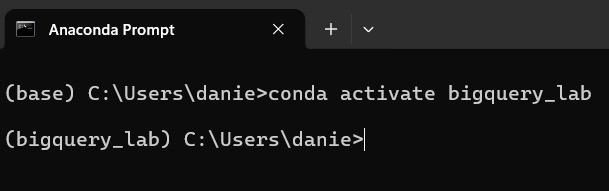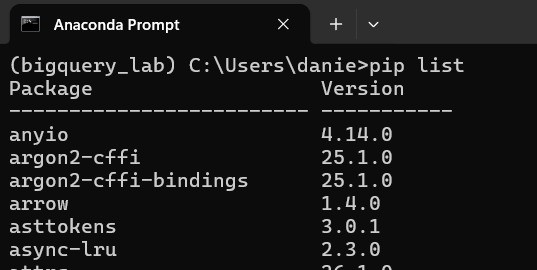


# Parte 2 - Configuración de Google Cloud

## Crear Proyecto

Para iniciar el desarrollo del Data Warehouse fue necesario crear un proyecto en Google Cloud Platform (GCP), el cual permite administrar los recursos y servicios que se utilizarán durante la práctica.

Los pasos realizados fueron los siguientes:

- Se ingresó a Google Cloud Console.
- Se seleccionó la opción Nuevo Proyecto.
- Se asignó un nombre al proyecto retail-analytics-lab
- Se confirmó la creación del proyecto y se esperó a que estuviera disponible.

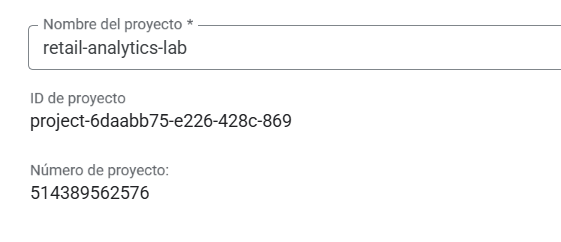

## Habilitar BigQuery API

Una vez creado el proyecto, fue necesario habilitar el servicio de BigQuery para permitir la creación de datasets, tablas y la ejecución de consultas SQL desde la plataforma y desde Python.

Los pasos realizados fueron:

Dentro del proyecto se accedió al menú APIs & Services, luego se seleccionó la opción  Enable APIs and Services, en el buscador se escribió BigQuery API y finalmente se hizo clic en Enable, habilitando la API para el proyecto.

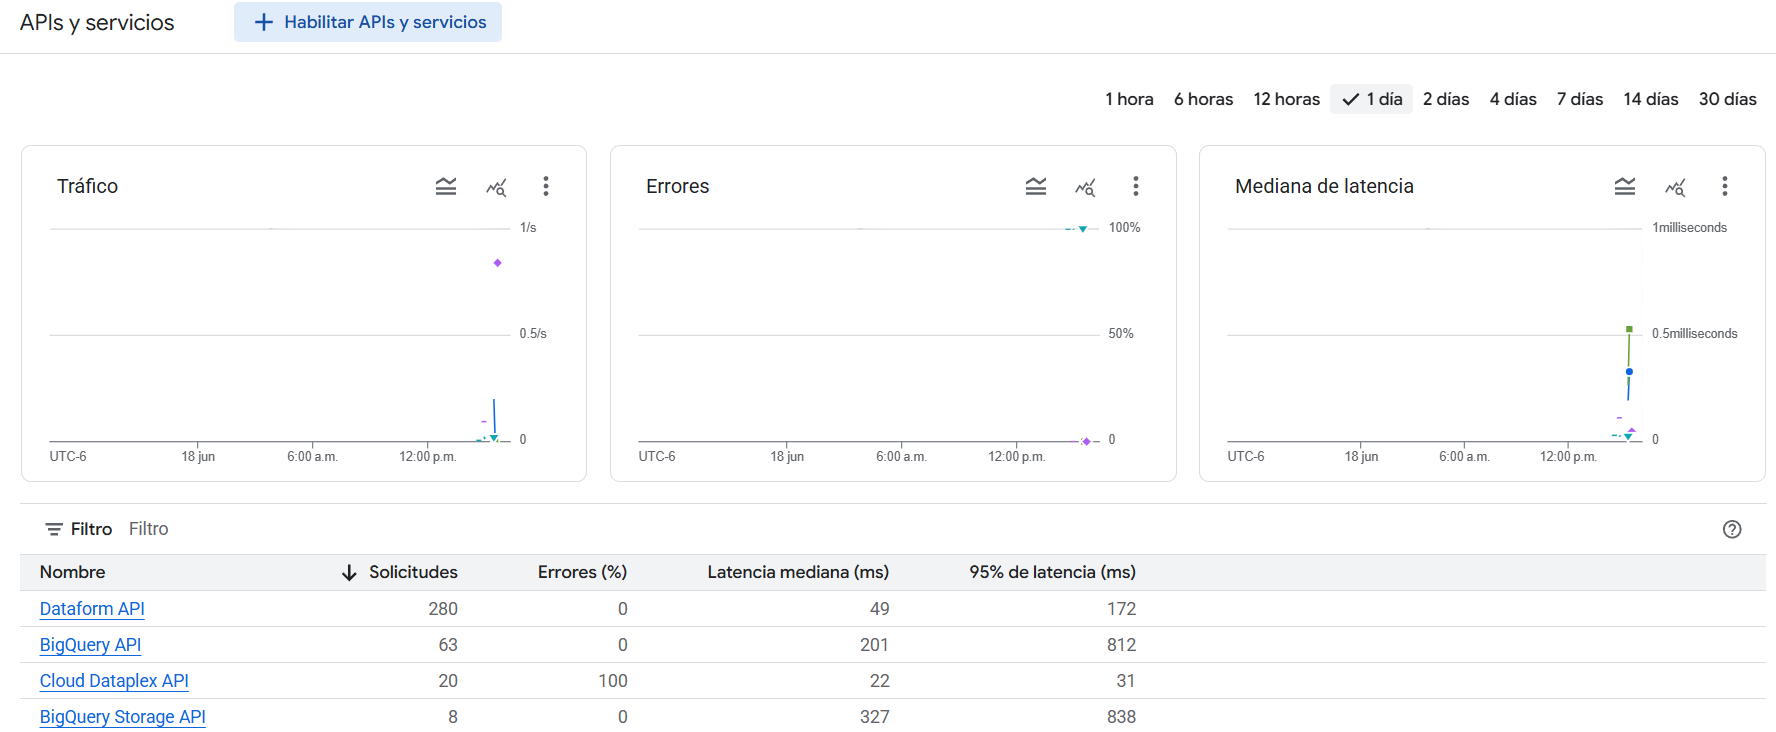

## Creación de la Service Account y descarga de credenciales 


Para permitir la conexión entre nuestro entorno local (Jupyter Notebook) y Google BigQuery, fue necesario crear una cuenta de servicio (Service Account) en Google Cloud Platform (GCP). Este proceso consiste en los siguientes pasos:

**Acceso a la consola de Google Cloud**

Se ingresó a la consola de GCP con las credenciales del proyecto **retail-analytics-lab** (Project ID: **project-6daabb75-e226-428c-869**).

**Creación de la Service Account**

Se navegó a: IAM & Administración → Cuentas de servicio

Posteriormente:

- Se hizo clic en Crear cuenta de servicio.
- Se configuró la cuenta con los siguientes datos:
  - Nombre: `bigquery`
  - ID de cuenta: `bigquery`
  - Descripción:*"Cuenta de servicio para conectar Python con BigQuery desde el proyecto, para leer las consultas".*

**Asignación de permisos (roles)**

Se otorgó el rol Administrador de bases de datos (`roles/bigquery.admin`).

Este rol permite realizar todas las operaciones necesarias sobre BigQuery (crear datasets, tablas, ejecutar consultas, etc.) sin otorgar permisos excesivos sobre otros servicios de GCP.

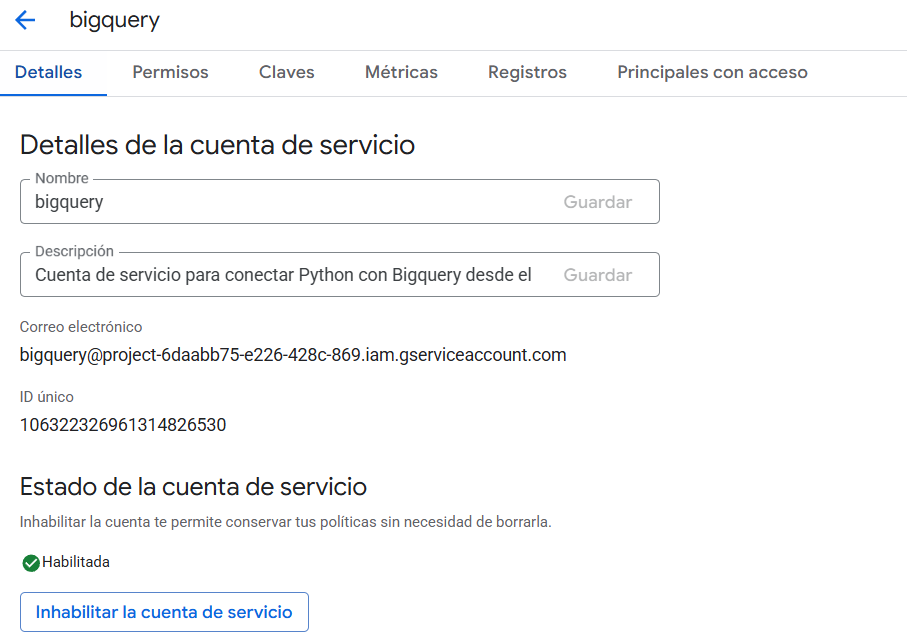

# Parte 3 - Conexión desde Python

Una vez configurado el proyecto en Google Cloud Platform y habilitada la API de BigQuery, se procedió a establecer la conexión desde Python utilizando la biblioteca google-cloud-bigquery. Esta biblioteca proporciona una interfaz que permite interactuar con BigQuery de forma programática, facilitando la creación de datasets, la carga de información y la ejecución de consultas SQL sin necesidad de realizar estas tareas directamente desde la consola web.

Para realizar la autenticación se utilizó una cuenta de servicio, cuyas credenciales fueron descargadas previamente en formato JSON y almacenadas en la carpeta credentials del proyecto. Antes de iniciar la conexión, el programa verifica que dicho archivo exista mediante la biblioteca os. Esta validación permite detectar de forma anticipada si las credenciales no se encuentran en la ubicación esperada, evitando errores durante el proceso de autenticación.

Una vez confirmada la existencia del archivo de credenciales, se creó una instancia del cliente de BigQuery mediante el método bigquery.Client.from_service_account_json(), indicando la ruta del archivo JSON y el identificador del proyecto de Google Cloud. Este cliente representa la conexión entre la aplicación desarrollada en Python y los servicios de BigQuery, permitiendo ejecutar todas las operaciones necesarias durante el desarrollo del proyecto.

Finalmente, al establecerse la conexión correctamente, el programa mostró un mensaje de confirmación junto con el identificador del proyecto, verificando que la autenticación fue exitosa y que el entorno quedó preparado para realizar la creación de datasets, tablas, carga de archivos CSV y consultas analíticas.

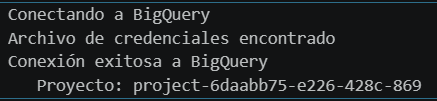

# Parte 4 - Creación del Dataset

Se procedió a la creación del dataset retail_dw en BigQuery, el cual funcionará como contenedor principal para todas las tablas del Data Warehouse de Retail Data Group.

Una vez creado el dataset retail_dw, se procedió a la construcción de las tres tablas principales que conforman el Data Warehouse. Cada tabla fue diseñada según el modelo de datos propuesto.

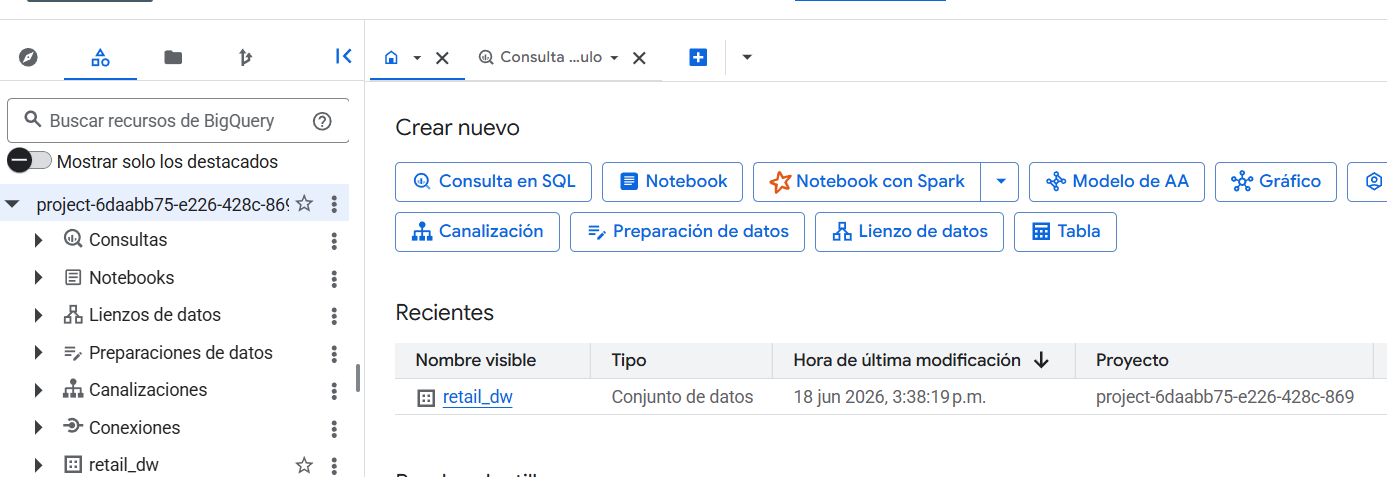

# Parte 5 - Construcción de Tablas

Una vez creado el dataset retail_dw, se procedió a la construcción de las tres tablas principales que conforman el Data Warehouse. Cada tabla fue diseñada según el modelo de datos propuesto.

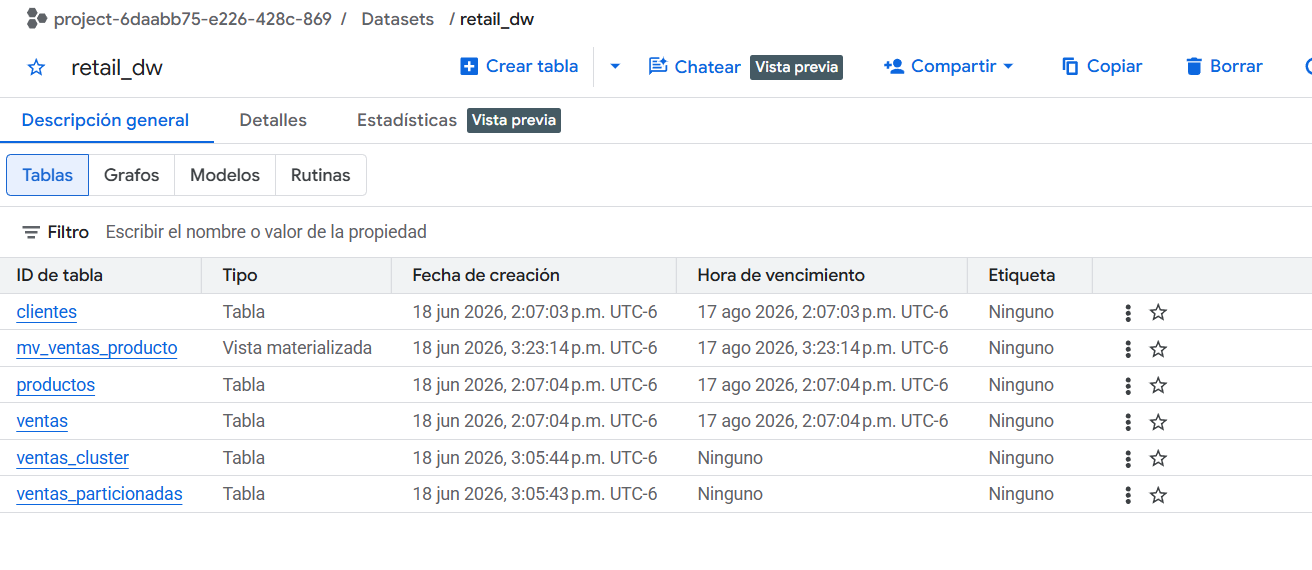

# Parte 6 - Generación de Datos con Python

En esta fase del proyecto se realizó la simulación de datos para el Data Warehouse utilizando Python, con el objetivo de generar información coherente y estructurada para su posterior análisis en BigQuery.

Se generaron tres conjuntos de datos principales:

- 5,000 registros de clientes
- 500 registros de productos
- 100,000 registros de ventas

Para la construcción de estos datos se utilizaron herramientas de Python orientadas a la generación y manipulación de datos:

Pandas para la creación y estructuración de los datos en formato tabular.
Random para la generación de valores aleatorios dentro de rangos definidos.
Faker para la creación de información ficticia realista, principalmente utilizada en la generación de nombres de clientes.

El proceso consistió en la creación de reglas de generación para cada entidad del modelo:

Los clientes fueron generados con identificadores únicos, nombres ficticios y asignación aleatoria a los países definidos en el caso de negocio.
Los productos fueron construidos con identificadores secuenciales, nombres representativos y categorías predefinidas para asegurar consistencia en el análisis.
Las ventas fueron generadas como la tabla de hechos, asociando clientes y productos mediante sus identificadores, asignando fechas dentro del año 2026, sucursales según los países del negocio y montos de compra simulados dentro de un rango realista.

Finalmente, los datos generados fueron estructurados en DataFrames y exportados en archivos CSV independientes:

- clientes.csv
- productos.csv
- ventas.csv

Estos archivos constituyen la base de datos del proyecto y serán utilizados posteriormente para su carga en Google BigQuery y el desarrollo de consultas analíticas.

# Parte 7 - Carga de Datos en BigQuery

Una vez generados los archivos clientes.csv, productos.csv y ventas.csv, se procedió a cargar la información en las tablas previamente creadas dentro del dataset retail_dw en BigQuery. Este proceso permitió almacenar los datos de manera centralizada para su posterior análisis mediante consultas SQL.

La carga de los archivos se realizó desde la interfaz de BigQuery, seleccionando la tabla de destino correspondiente para cada archivo CSV. Durante el proceso se verificó que el formato de los datos coincidiera con la estructura definida en las tablas, respetando los tipos de datos establecidos para cada columna, como identificadores numéricos, cadenas de texto, fechas y valores monetarios.

Una vez finalizada la importación, se comprobó que la información hubiera sido cargada correctamente mediante consultas de validación. En particular, se utilizó la instrucción SELECT COUNT(*) sobre la tabla ventas para verificar que se hubieran importado los 100,000 registros generados durante la etapa de creación de datos. Asimismo, se revisó la vista previa de las tablas para confirmar que la información fuera consistente y estuviera disponible para las consultas analíticas posteriores.

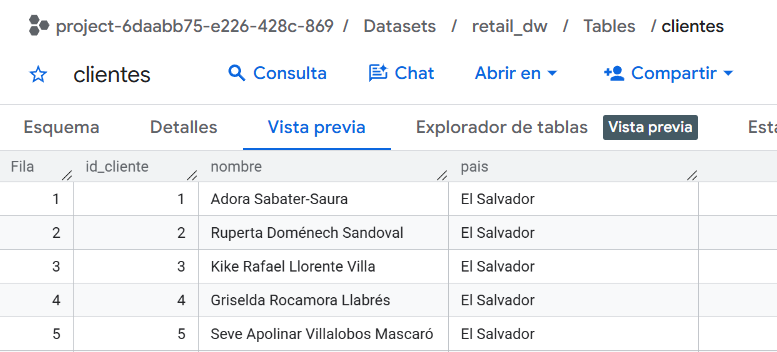
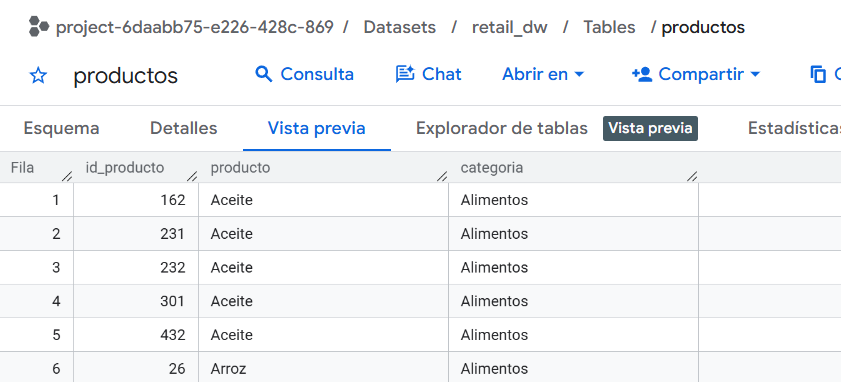
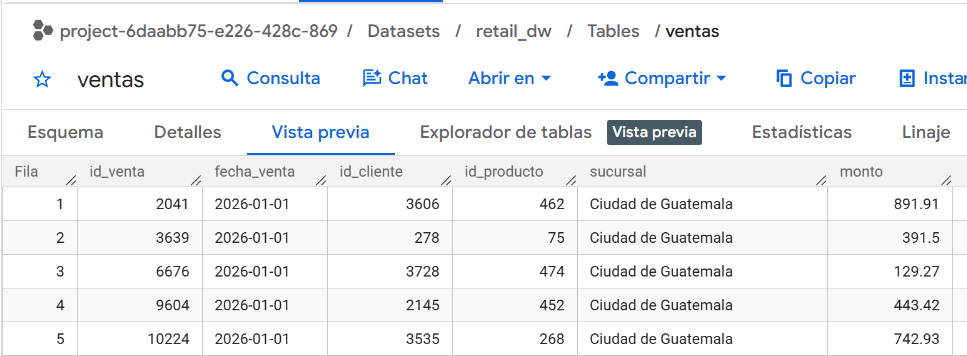

# Parte 8 - Consultas Analíticas

Una vez cargados los datos en BigQuery, se desarrollaron diversas consultas SQL con el propósito de obtener información relevante para la toma de decisiones. Estas consultas permitieron analizar el comportamiento de las ventas desde diferentes perspectivas, aprovechando la estructura del Data Warehouse y las relaciones existentes entre las tablas de clientes, productos y ventas.

**Top 10 productos con mayores ventas**

La primera consulta tuvo como objetivo identificar los diez productos que generaron el mayor monto de ventas. Para ello, se realizó una unión (JOIN) entre las tablas ventas y productos utilizando el identificador del producto como llave de relación. Posteriormente, se sumó el monto de todas las ventas correspondientes a cada producto, ordenando los resultados de forma descendente para mostrar únicamente los diez productos con mejor desempeño.

Esta información permite identificar los productos más exitosos dentro de la empresa, facilitando la toma de decisiones relacionadas con estrategias comerciales, control de inventarios y campañas de promoción.

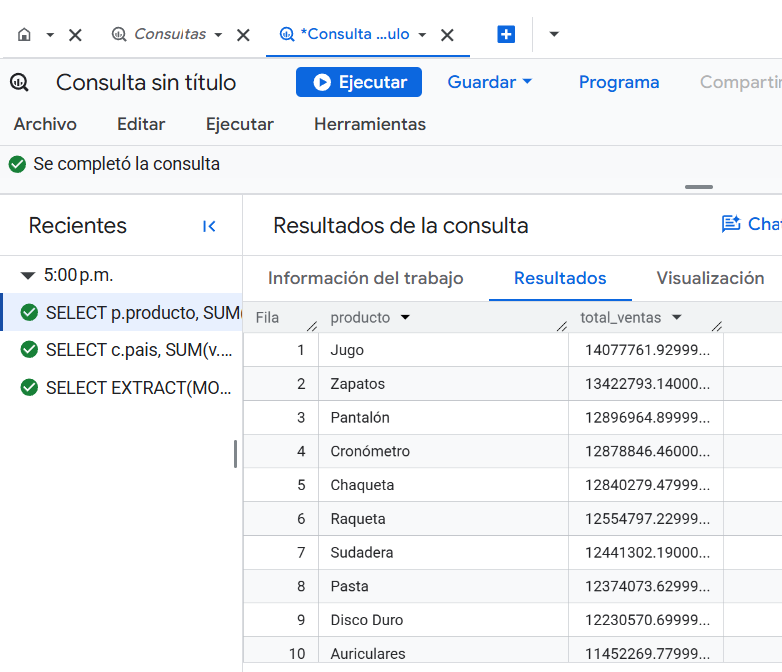

**Ventas por país**

La segunda consulta se enfocó en determinar el monto total de ventas generado en cada país donde opera la empresa. Para ello, se relacionaron las tablas ventas y clientes mediante el identificador del cliente, obteniendo el país asociado a cada venta. Finalmente, se realizó una suma del monto vendido por país.

El resultado de esta consulta permite comparar el desempeño de cada mercado y conocer cuáles países aportan una mayor participación en los ingresos totales de la organización, proporcionando información útil para la planificación estratégica y la distribución de recursos.

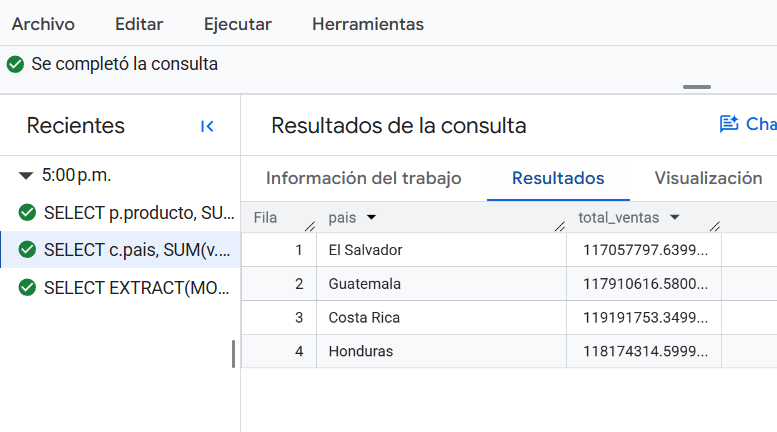

**Tendencia mensual de ventas**

La tercera consulta tuvo como finalidad analizar el comportamiento de las ventas a lo largo del año. Para ello, se extrajo el mes de la fecha de venta utilizando la función EXTRACT(MONTH FROM fecha_venta) y posteriormente se calculó el total vendido en cada mes mediante la suma de los montos registrados.

El análisis de la tendencia mensual permite identificar períodos de mayor y menor actividad comercial, detectar patrones de comportamiento en las ventas y proporcionar información que facilite la planificación de inventarios, campañas de mercadeo y proyecciones financieras.

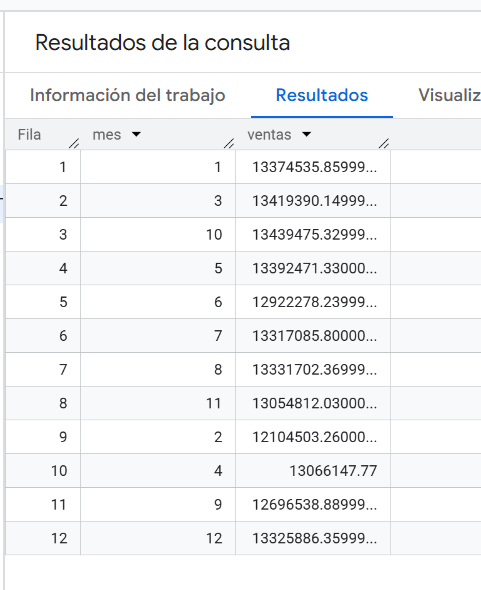


# Parte 9 - Optimización

En esta fase del proyecto se aplicaron técnicas de optimización en BigQuery con el objetivo de mejorar el rendimiento de las consultas analíticas y reducir el costo de procesamiento de datos.

Se implementaron dos estrategias principales: particionamiento y clustering, ambas aplicadas sobre la tabla de ventas, la cual representa la tabla de hechos del modelo de datos.

**Particionamiento**

Se creó una versión particionada de la tabla de ventas utilizando la columna de fecha de venta como criterio de partición.

Esta estrategia permite que BigQuery divida físicamente los datos en segmentos basados en la fecha, lo que mejora significativamente el rendimiento de las consultas que filtran por rangos de tiempo, ya que el sistema solo procesa las particiones necesarias en lugar de escanear toda la tabla.

**Clustering**

Adicionalmente, se creó una versión clusterizada de la tabla de ventas, aplicando clustering sobre la columna sucursal.

El clustering organiza los datos dentro de cada partición según el valor de la columna seleccionada, lo que optimiza las consultas que realizan filtros o agrupaciones por sucursal, mejorando la eficiencia del procesamiento y reduciendo el volumen de datos analizados.

**Comparación de rendimiento**

Para evaluar el impacto de estas optimizaciones, se realizarán pruebas comparativas entre las tablas originales, particionadas y clusterizadas.

Se analizarán métricas como el tiempo de ejecución de las consultas y la cantidad de datos procesados por BigQuery.

Estos resultados permitirán evidenciar las mejoras en eficiencia y justificar la implementación de técnicas de optimización dentro del Data Warehouse.

**Resultados de pruebas**

**consulta de tabla sin optimizar**

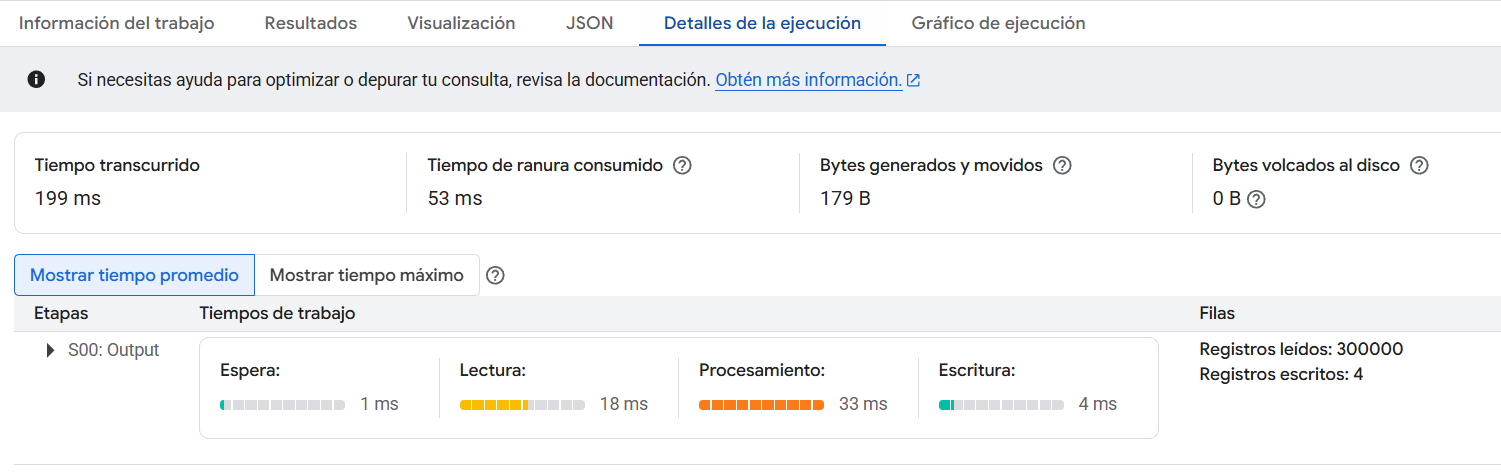

**Consulta en tabla PARTICIONADA (ventas_particionadas)**

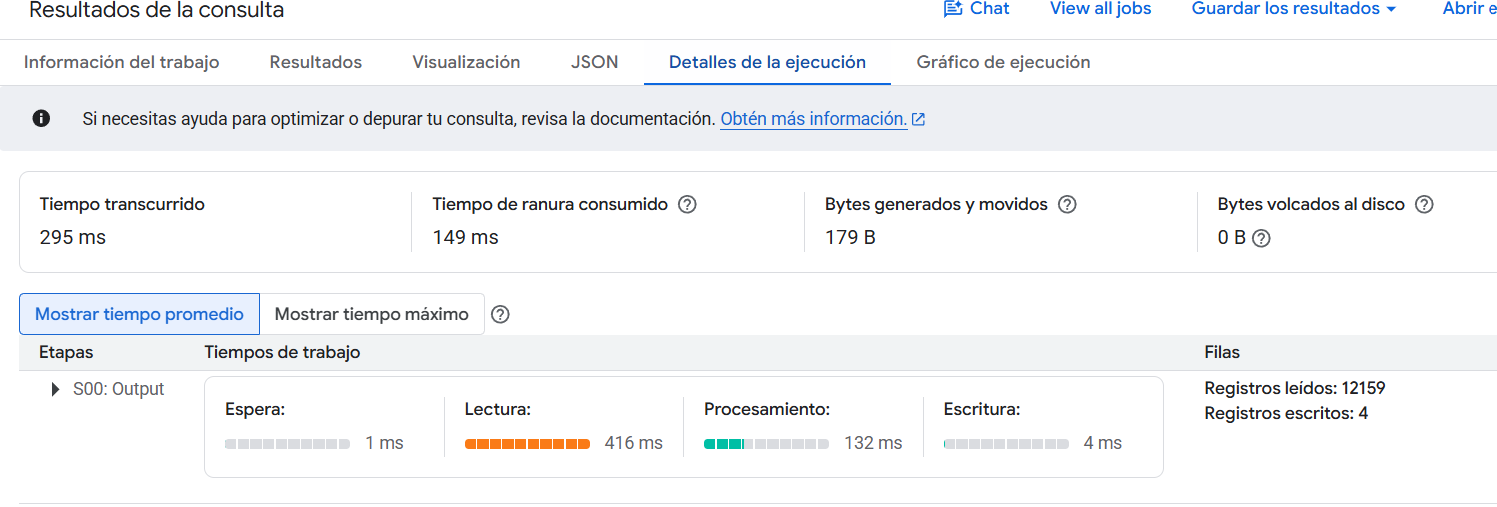

**Consulta en tabla (ventas_cluster)**

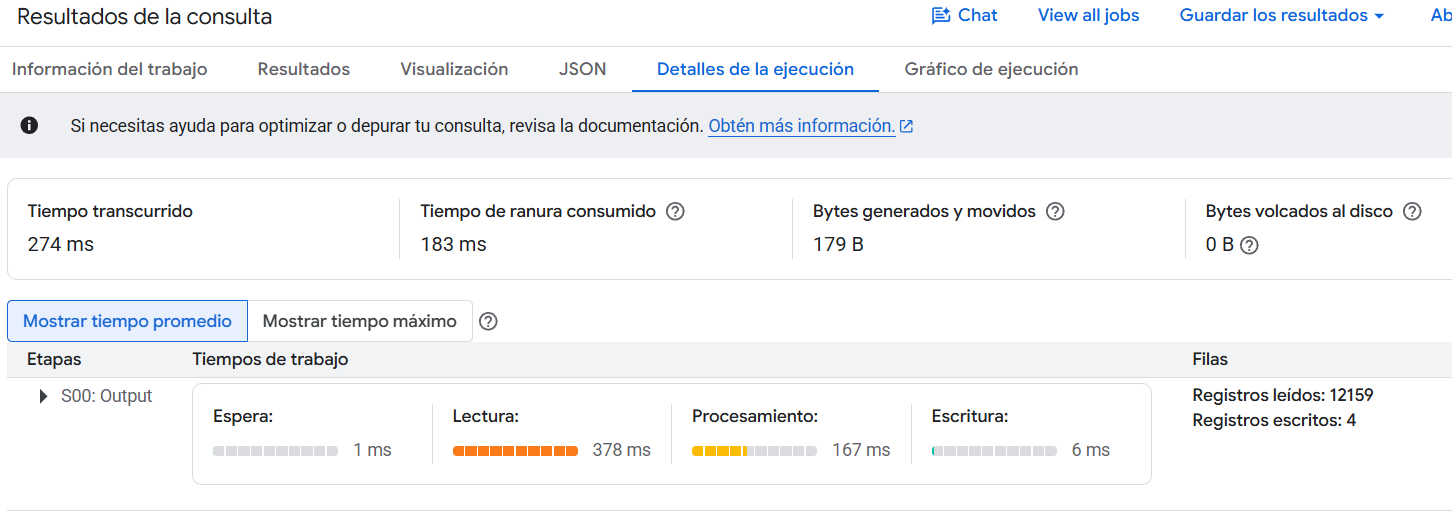


**Conclusión de la optimización**

Durante las pruebas de rendimiento se comparó la ejecución de la misma consulta sobre una tabla sin optimizar, una tabla particionada y una tabla particionada con clustering. Aunque las tablas optimizadas presentaron tiempos de respuesta ligeramente superiores, se observó una reducción significativa en la cantidad de registros escaneados, lo que evidencia que las estrategias de optimización fueron aplicadas correctamente.

**Resumen de resultados**

| Tipo de tabla | Tiempo de ejecución | Registros leídos | Interpretación |
|:---|---:|---:|:---|
| Sin optimizar | 199 ms | 300,000 | Se escaneó la totalidad de la tabla. |
| Particionada | 295 ms | 12,159 | El particionamiento permitió leer únicamente las particiones correspondientes al rango de fechas consultado. |
| Particionada + Clustering | 275 ms | 12,159 | Se mantuvo la reducción de registros leídos y se obtuvo una ligera mejora respecto a la tabla solo particionada. |

**Conclusión:** Aunque la tabla sin optimizar obtuvo el menor tiempo de ejecución, esto se debe a que el conjunto de datos utilizado fue relativamente pequeño (300,000 registros), permitiendo que BigQuery procesara rápidamente la tabla completa. No obstante, las tablas optimizadas redujeron en aproximadamente 96 % la cantidad de registros leídos, demostrando que el particionamiento y el clustering funcionan correctamente. Estas técnicas cobran mayor relevancia cuando se trabaja con grandes volúmenes de datos, ya que contribuyen a disminuir el costo de procesamiento y mejorar la eficiencia de las consultas.

# Parte 10 - Materialized View

En esta fase del proyecto se implementó una vista materializada en BigQuery con el objetivo de optimizar consultas recurrentes relacionadas con el análisis de ventas por producto.

La vista materializada fue creada a partir de la tabla de ventas, realizando una agregación del monto total por producto. Esto permite almacenar previamente los resultados calculados, evitando que BigQuery tenga que recalcular la agregación cada vez que se ejecuta la consulta.

El uso de esta técnica mejora significativamente el rendimiento de las consultas analíticas, especialmente en escenarios donde se realizan consultas repetitivas sobre grandes volúmenes de datos.

Además, se realizó la verificación del funcionamiento de la vista materializada, evaluando la rapidez de respuesta en comparación con una consulta tradicional sobre la tabla base.

**Verificación de rendimiento**

**(sin Materialized View)**

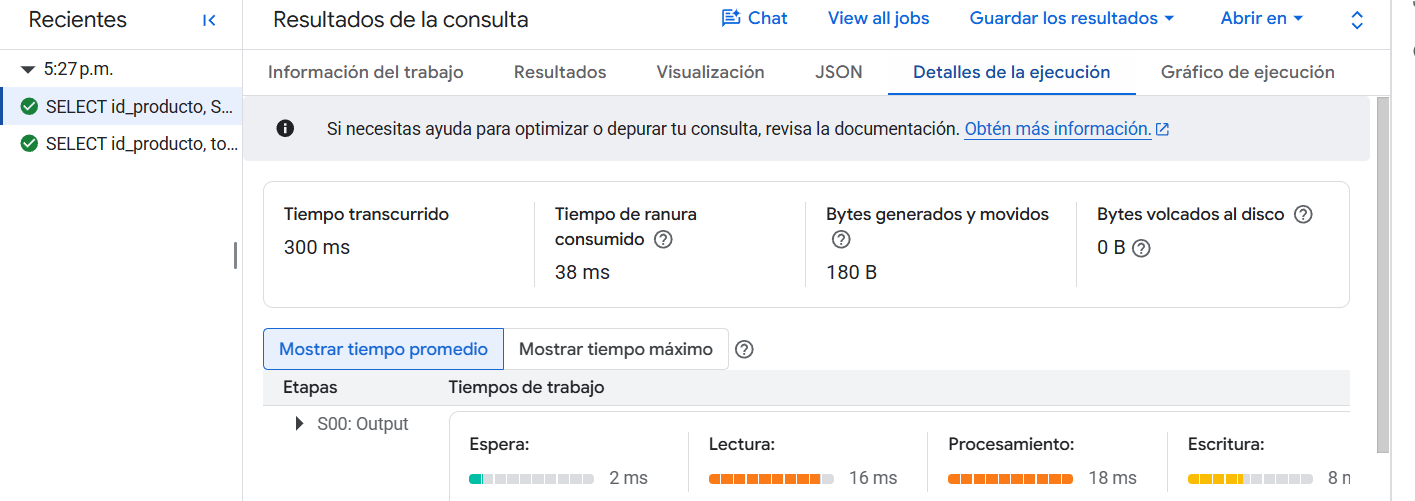

**(con Materialized View)**

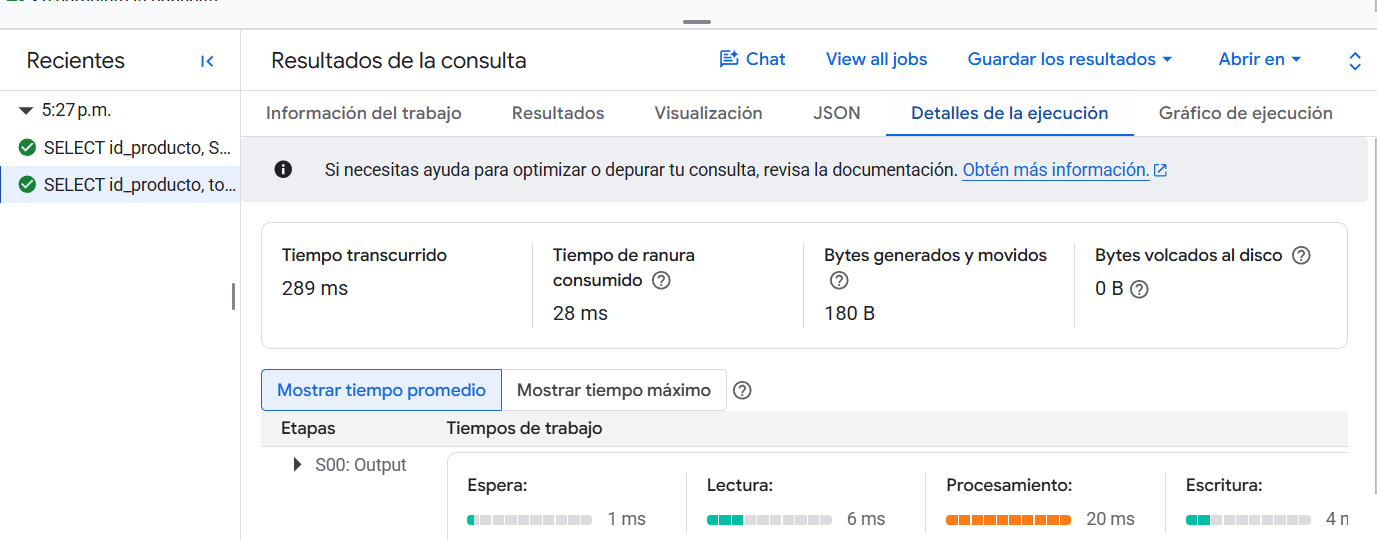

**Conclusión del uso de Materialized View**

Se comparó la ejecución de una consulta de agregación realizada directamente sobre la tabla de ventas con la misma consulta ejecutada a través de una **Materialized View** previamente calculada. Los resultados muestran una ligera mejora en el tiempo de respuesta al utilizar la vista materializada, evidenciando que esta estrategia puede optimizar consultas repetitivas que requieren agregaciones frecuente.

**Resumen de resultados**

| Consulta | Tiempo de ejecución | Interpretación |
|:---|---:|:---|
| Tabla original (`ventas`) | 300 ms | BigQuery calculó la suma de ventas por producto directamente sobre la tabla base. |
| Materialized View (`mv_ventas_producto`) | 289 ms | Se aprovecharon los resultados precomputados de la vista materializada, reduciendo el tiempo de procesamiento. |

**Conclusión:** La Materialized View presentó un tiempo de ejecución ligeramente menor (289 ms) en comparación con la consulta realizada directamente sobre la tabla original (300 ms). Aunque la diferencia fue pequeña debido al tamaño moderado del conjunto de datos, los resultados demuestran que las vistas materializadas pueden mejorar el rendimiento al reutilizar agregaciones previamente almacenadas. Su principal beneficio se aprecia en entornos con grandes volúmenes de información y consultas analíticas ejecutadas de forma recurrente, donde contribuyen a disminuir los tiempos de respuesta y el consumo de recursos.

# Parte 11 - Dashboard Exploratorio en Python

In [4]:
from IPython.display import display, HTML

resumen = """
<h1>Dashboard Exploratorio - Retail Data Group</h1>
<hr>

<h2>Resumen Ejecutivo</h2>
<table border="1" style="border-collapse:collapse; width:50%; text-align:left;">
  <tr style="background-color:#f2f2f2;">
    <th style="padding:8px;">Indicador</th>
    <th style="padding:8px;">Valor</th>
  </tr>
  <tr><td style="padding:8px;">Total de ventas</td><td style="padding:8px;">$52,481,609.13</td></tr>
  <tr><td style="padding:8px;">Numero de transacciones</td><td style="padding:8px;">100,000</td></tr>
  <tr><td style="padding:8px;">Ticket promedio</td><td style="padding:8px;">$524.82</td></tr>
  <tr><td style="padding:8px;">Venta minima</td><td style="padding:8px;">$50.01</td></tr>
  <tr><td style="padding:8px;">Venta maxima</td><td style="padding:8px;">$999.97</td></tr>
</table>

<hr>
<h2>Highlights Principales</h2>
<p><b>Pais con mas ventas:</b> Costa Rica — $13,243,528.15</p>
<p><b>Producto mas vendido:</b> Jugo — $1,564,195.77</p>
<p><b>Sucursal con mejores ventas:</b> Ciudad de Guatemala — $13,194,564.66</p>

<hr>
<h2>Distribucion de Ventas por Pais</h2>
<table border="1" style="border-collapse:collapse; width:60%; text-align:left;">
  <tr style="background-color:#f2f2f2;">
    <th style="padding:8px;">Pais</th>
    <th style="padding:8px;">Ventas</th>
    <th style="padding:8px;">Participacion</th>
  </tr>
  <tr><td style="padding:8px;">Costa Rica</td><td style="padding:8px;">$13,243,528.15</td><td style="padding:8px;">25.2%</td></tr>
  <tr><td style="padding:8px;">Honduras</td><td style="padding:8px;">$13,130,479.40</td><td style="padding:8px;">25.0%</td></tr>
  <tr><td style="padding:8px;">Guatemala</td><td style="padding:8px;">$13,101,179.62</td><td style="padding:8px;">25.0%</td></tr>
  <tr><td style="padding:8px;">El Salvador</td><td style="padding:8px;">$13,006,421.96</td><td style="padding:8px;">24.8%</td></tr>
</table>

<hr>
<h2>Top 3 Categorias por Ventas</h2>
<table border="1" style="border-collapse:collapse; width:50%; text-align:left;">
  <tr style="background-color:#f2f2f2;">
    <th style="padding:8px;">Posicion</th>
    <th style="padding:8px;">Categoria</th>
    <th style="padding:8px;">Ventas Totales</th>
  </tr>
  <tr><td style="padding:8px;">1</td><td style="padding:8px;">Tecnologia</td><td style="padding:8px;">$11,653,450.05</td></tr>
  <tr><td style="padding:8px;">2</td><td style="padding:8px;">Ropa</td><td style="padding:8px;">$11,235,041.40</td></tr>
  <tr><td style="padding:8px;">3</td><td style="padding:8px;">Hogar</td><td style="padding:8px;">$10,072,439.14</td></tr>
</table>

"""

display(HTML(resumen))

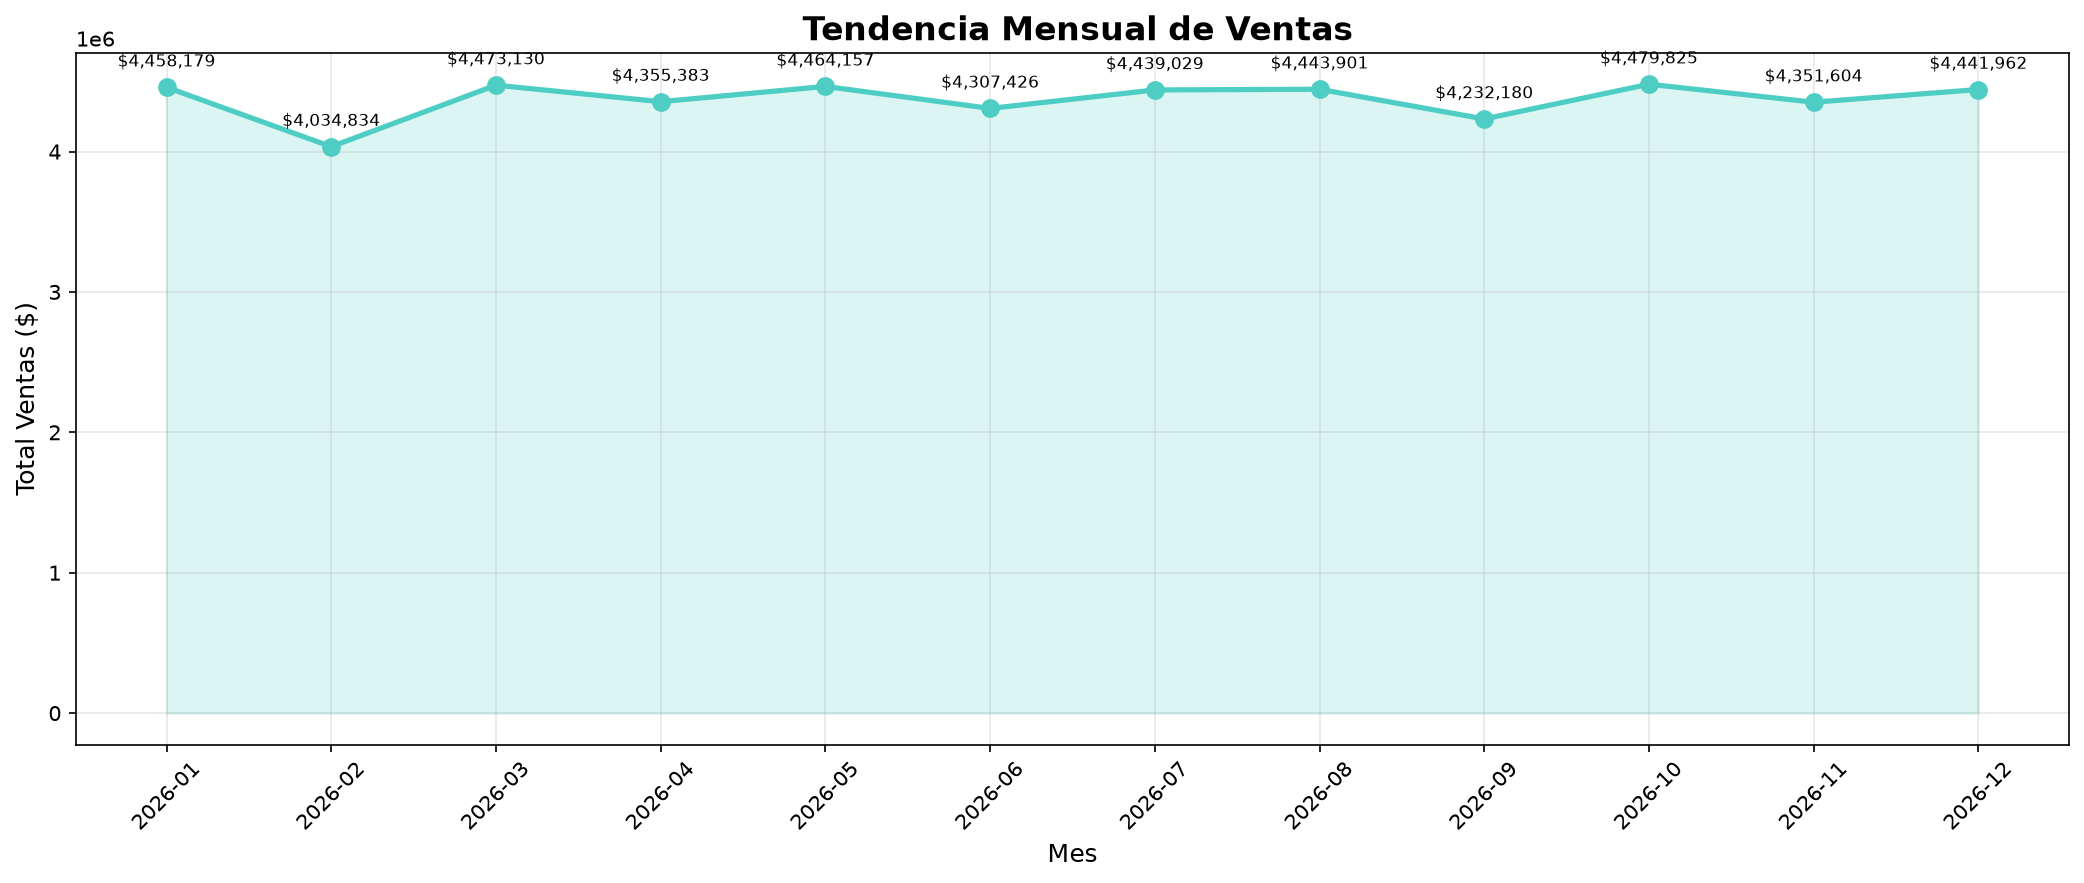
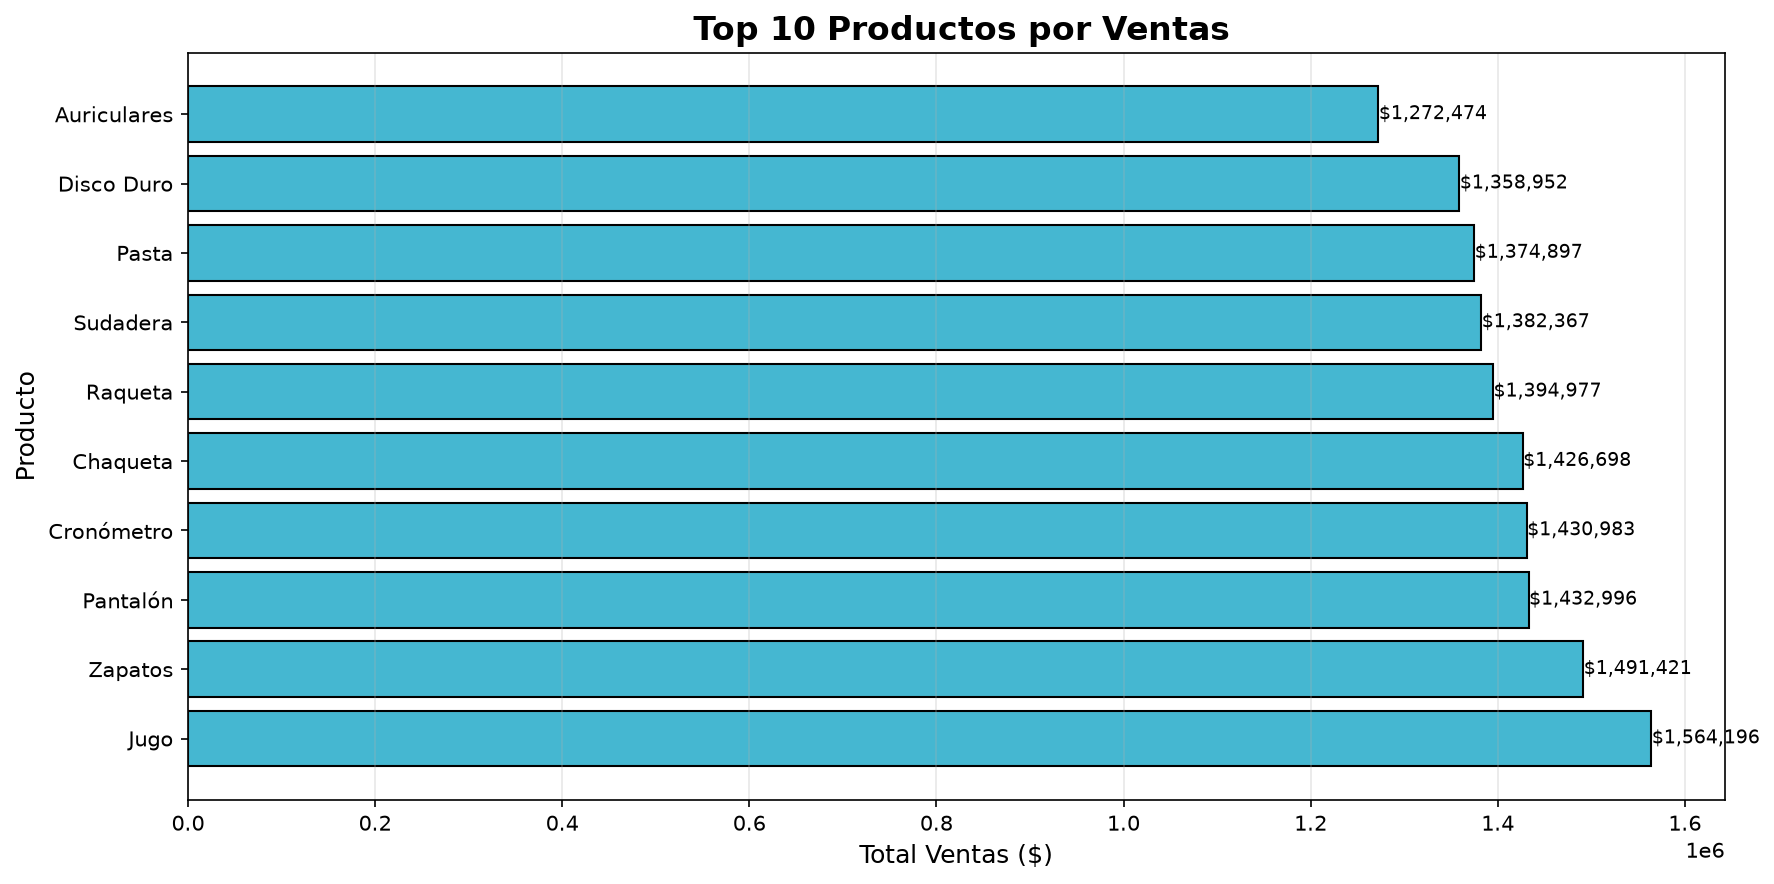
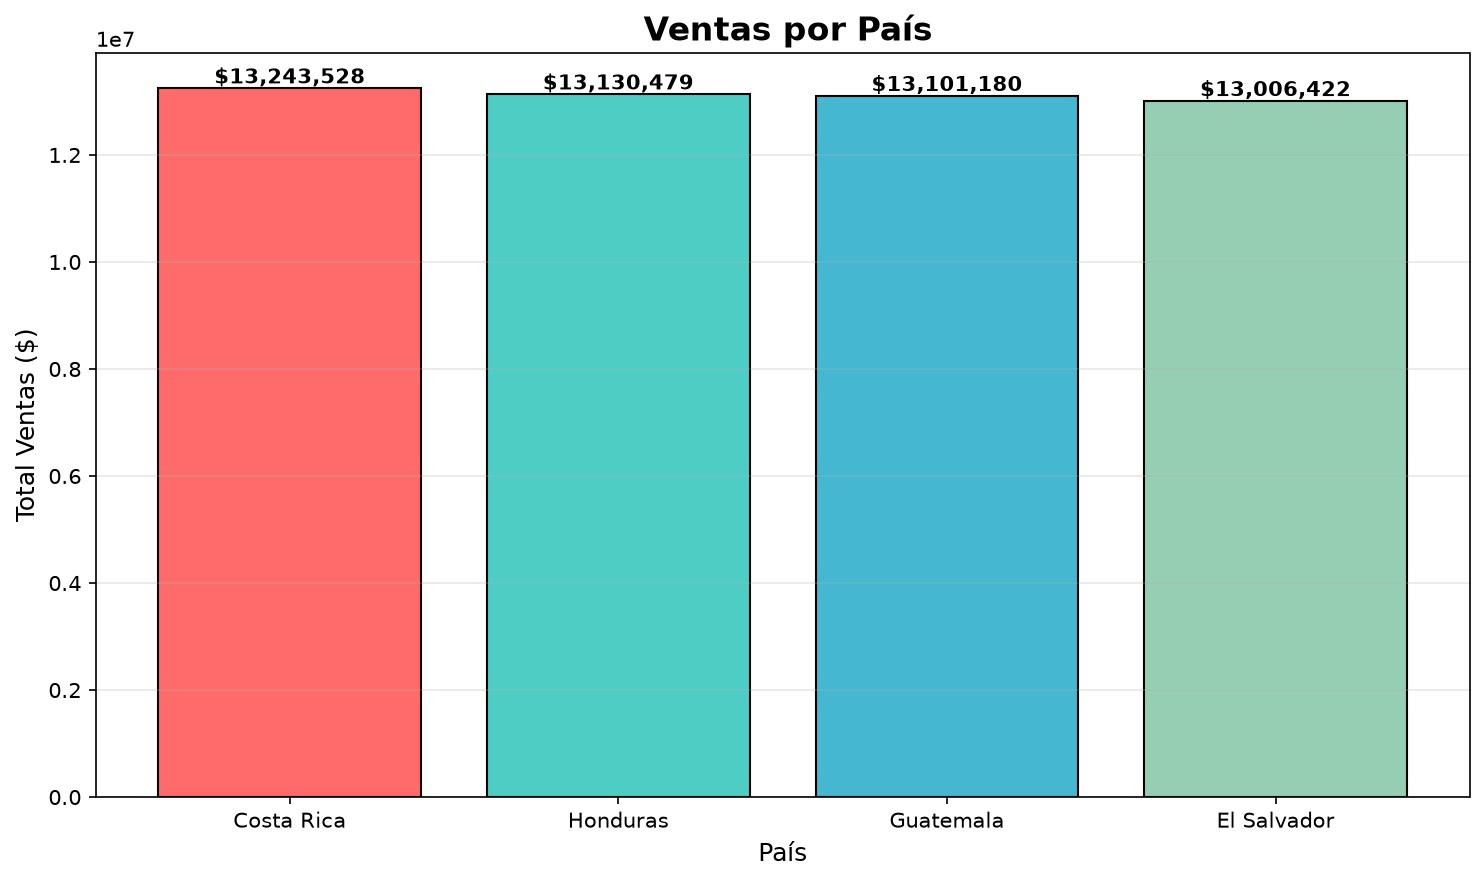
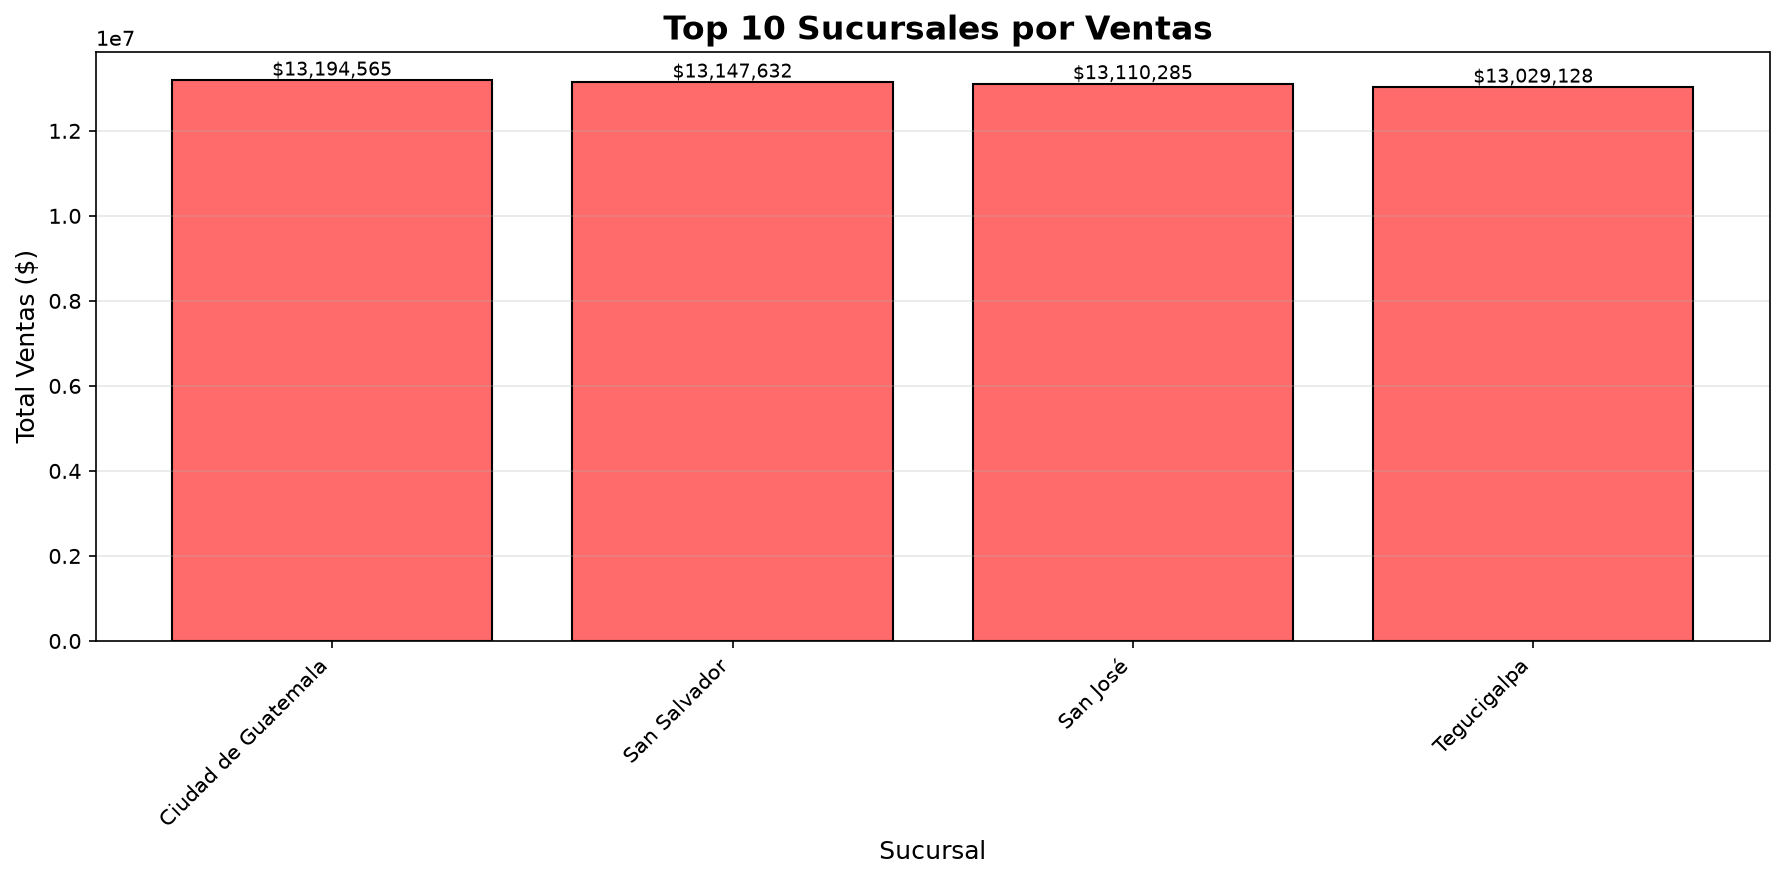

## Conclusiones

### Conclusiones Técnicas

1. **Implementación exitosa de un Data Warehouse en BigQuery:** Se logró centralizar la información de ventas de Retail Data Group (Guatemala, El Salvador, Honduras y Costa Rica) en un modelo dimensional dentro del dataset `retail_dw`, conformado por las tablas `clientes`, `productos` y `ventas`, con un total de 100,000 registros de transacciones cargados y validados correctamente.

2. **El particionamiento y clustering reducen el escaneo de datos en ~96%:** Las pruebas comparativas demostraron que, aunque la tabla sin optimizar presentó menor tiempo de ejecución (199 ms vs. 295 ms), las tablas particionadas y clusterizadas redujeron los registros leídos de 300,000 a tan solo 12,159. Esto evidencia que estas técnicas son críticas cuando el volumen de datos escala, ya que el beneficio en costo y rendimiento se incrementa proporcionalmente al tamaño del dataset.

3. **Las Materialized Views ofrecen ventajas en consultas agregadas recurrentes:** La vista materializada `mv_ventas_producto` redujo el tiempo de ejecución de 300 ms a 289 ms al reutilizar resultados precomputados. Aunque la mejora fue modesta con el dataset actual, esta estrategia cobra relevancia en entornos productivos con grandes volúmenes y consultas analíticas frecuentes.

4. **La distribución geográfica de ventas es prácticamente uniforme:** Los datos analíticos revelaron que los cuatro países presentan una participación muy similar en las ventas totales ($52,481,609.13), con Costa Rica liderando con un 25.2% y El Salvador como el mercado de menor participación con un 24.8%. Esto indica que la generación de datos simulados fue coherente y que el modelo analítico funciona correctamente para consultas por región.

5. **La autenticación mediante Service Account garantiza el principio de menor privilegio:** Se configuró una cuenta de servicio con el rol `roles/bigquery.admin`, lo que permite realizar todas las operaciones necesarias sobre BigQuery (crear datasets, tablas, ejecutar consultas) sin otorgar permisos sobre otros servicios de GCP. Este enfoque es alineado con las buenas prácticas de seguridad en entornos cloud.

---
### Recomendaciones de Mejora

1. **Incluir validación de datos antes de la carga en BigQuery:** En el notebook de generación de datos, se recomienda agregar verificaciones explícitas con `pandas` (como `df.isnull().sum()`, `df.duplicated().sum()` y validación de rangos) antes de exportar los archivos CSV y cargarlos en BigQuery. Esto garantiza la integridad del dataset desde el origen y es una buena práctica en cualquier pipeline de datos.

2. **Ampliar las consultas analíticas con métricas adicionales:** Las consultas actuales cubren top productos, ventas por país y tendencia mensual, pero se podría enriquecer el análisis incorporando consultas como: clientes con mayor ticket promedio, productos con menor rotación por categoría, o comparativa de sucursales por mes. Esto demostraría un mayor dominio de SQL analítico y aprovecharía mejor la estructura del Data Warehouse construido.

3. **Documentar cada notebook con celdas Markdown explicativas:** Actualmente el reporte centraliza la documentación, pero se recomienda que cada notebook (`01_conexion_bigquery.ipynb`, `02_generacion_datos.ipynb`, etc.) incluya celdas Markdown con el objetivo de la sección, descripción del código y los resultados obtenidos. Esto hace el proyecto más legible, reproducible y alineado con los estándares de entrega académica.